# Когортный анализ retention

## Цель 1: Оценить месячный retention в оформление заказа

В рамках первой цели проекта были выполнены следующие задачи:
1. Предварительная обработка данных
2. Определение вида заказа, который будет учитываться в подсчете retention
3. Построение матрицы месячного retention
4. Расчет медианного retention 1-го месяца для всех когорт
5. Определить когорту с самым высоким retention на 3-й месяц
6. Визуализация месячного retention (построение хитмэп-карты)

Описание структуры используемых данных представлено в файле README проекта.

### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from operator import attrgetter

import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import seaborn as sns

### Импорт данных

In [2]:
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_order_items = pd.read_csv('olist_order_items_dataset.csv')

### Предварительная обработка данных

In [3]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


#### Объединение данных для получения уникальных пользователей

In [4]:
df_orders = pd.merge(df_orders, df_customers,
                       how='left', 
                       on='customer_id')
df_orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [5]:
# Подсчет количества по статусам задазов
df_orders.order_status.value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
# Создание копии данных, чтобы избежать изменений в исходном DataFrame
df_orders_copy = df_orders.copy()

#### Фильтрация по доставленным заказам

In [7]:
df_orders_copy = df_orders_copy.query("order_status == 'delivered'")
df_orders_copy.order_status.value_counts() # подсчет количества доставленных

order_status
delivered    96478
Name: count, dtype: int64

In [8]:
# Приведение даты создания заказа к формату 'Даты'
df_orders_copy['order_purchase_timestamp'] = pd.to_datetime(df_orders_copy['order_purchase_timestamp'])

In [9]:
# Месяц заказа
df_orders_copy['order_month'] = df_orders_copy['order_purchase_timestamp'].dt.to_period('M')

# Месяц первой покупки пользователя
df_orders_copy['cohort'] = df_orders_copy.groupby('customer_unique_id')['order_purchase_timestamp'] \
                                         .transform('min') \
                                         .dt.to_period('M')

In [10]:
# Разница между месяцами
df_orders_copy['period_number'] = (df_orders_copy['order_month'] - df_orders_copy['cohort']).apply(attrgetter('n'))

In [11]:
df_cohort = (
    df_orders_copy
    .groupby(['cohort', 'period_number'])
    .agg(n_customers=('customer_unique_id', 'nunique'))
    .reset_index()
)
df_cohort

,cohort,period_number,n_customers
0,2016-09,0,1
1,2016-10,0,262
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1
...,...,...,...
214,2018-06,1,25
215,2018-06,2,16
216,2018-07,0,5949
217,2018-07,1,31


In [12]:
cohort_pivot = df_cohort.pivot_table(
    index='cohort',
    columns='period_number',
    values='n_customers'
)
cohort_pivot

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN
2017-03,2503.0,11.0,9.0,10.0,9.0,4.0,4.0,8.0,8.0,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,3.0,NaN,NaN
2017-04,2256.0,14.0,5.0,4.0,6.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,1.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN
2017-05,3451.0,16.0,16.0,10.0,10.0,11.0,14.0,5.0,9.0,9.0,9.0,12.0,8.0,1.0,6.0,7.0,NaN,NaN,NaN,NaN
2017-06,3037.0,15.0,12.0,13.0,9.0,12.0,11.0,7.0,4.0,6.0,9.0,11.0,5.0,5.0,7.0,NaN,NaN,NaN,NaN,NaN


In [13]:
# Чистим полученный результат от данных 2016 года, так как он практически весь состоит из Nan'ов
cohort_pivot = cohort_pivot[cohort_pivot.index >= '2017-01']

#### Матрица месячного retention по когортам

In [14]:
# Рассчитываем размеры когорт (первый столбец сводной таблицы)
cohort_size = cohort_pivot.iloc[:, 0]

# Вычисление коэффициентов удержания (retention), деля на размер когорты
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
retention_matrix

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2017-01,1.0,0.002789,0.002789,0.001395,0.004184,0.001395,0.004184,0.001395,0.001395,NaN,0.004184,0.001395,0.006974,0.004184,0.001395,0.001395,0.002789,0.004184,0.001395,NaN
2017-02,1.0,0.001843,0.003071,0.001229,0.004300,0.001229,0.002457,0.001843,0.001229,0.001843,0.001229,0.003071,0.001229,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN
2017-03,1.0,0.004395,0.003596,0.003995,0.003596,0.001598,0.001598,0.003196,0.003196,0.000799,0.003596,0.001199,0.001998,0.001199,0.001598,0.002397,0.000799,0.001199,NaN,NaN
2017-04,1.0,0.006206,0.002216,0.001773,0.002660,0.002660,0.003546,0.003103,0.003103,0.001773,0.002660,0.000887,0.000443,0.000443,0.000887,0.000887,0.001330,NaN,NaN,NaN
2017-05,1.0,0.004636,0.004636,0.002898,0.002898,0.003187,0.004057,0.001449,0.002608,0.002608,0.002608,0.003477,0.002318,0.000290,0.001739,0.002028,NaN,NaN,NaN,NaN
2017-06,1.0,0.004939,0.003951,0.004281,0.002963,0.003951,0.003622,0.002305,0.001317,0.001976,0.002963,0.003622,0.001646,0.001646,0.002305,NaN,NaN,NaN,NaN,NaN
2017-07,1.0,0.005330,0.003465,0.002399,0.002932,0.002132,0.003198,0.001066,0.001866,0.002665,0.002132,0.002932,0.001333,0.002399,NaN,NaN,NaN,NaN,NaN,NaN
2017-08,1.0,0.006902,0.003451,0.002711,0.003451,0.005176,0.002958,0.002711,0.001479,0.001479,0.002465,0.001972,0.001232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09,1.0,0.006993,0.005495,0.002747,0.004496,0.002248,0.002248,0.002498,0.002747,0.001748,0.002498,0.000749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Расчет медианного retention 1-го месяца для всех когорт

In [15]:
# Медианный retention 1го месяца
median_retention_1m = retention_matrix[1].median()
median_retention_1m

0.004939084622983207

#### Когорта с самым высоким retention на 3-й месяц

In [16]:
retention_matrix[3].idxmax()

Period('2017-06', 'M')

#### Тепловая карта когортного анализа месячного retention

In [17]:
# Предварительно убираем из хитмапа зеленый столбец: нулевой месяц
retention_matrix = retention_matrix.iloc[:, 1:]

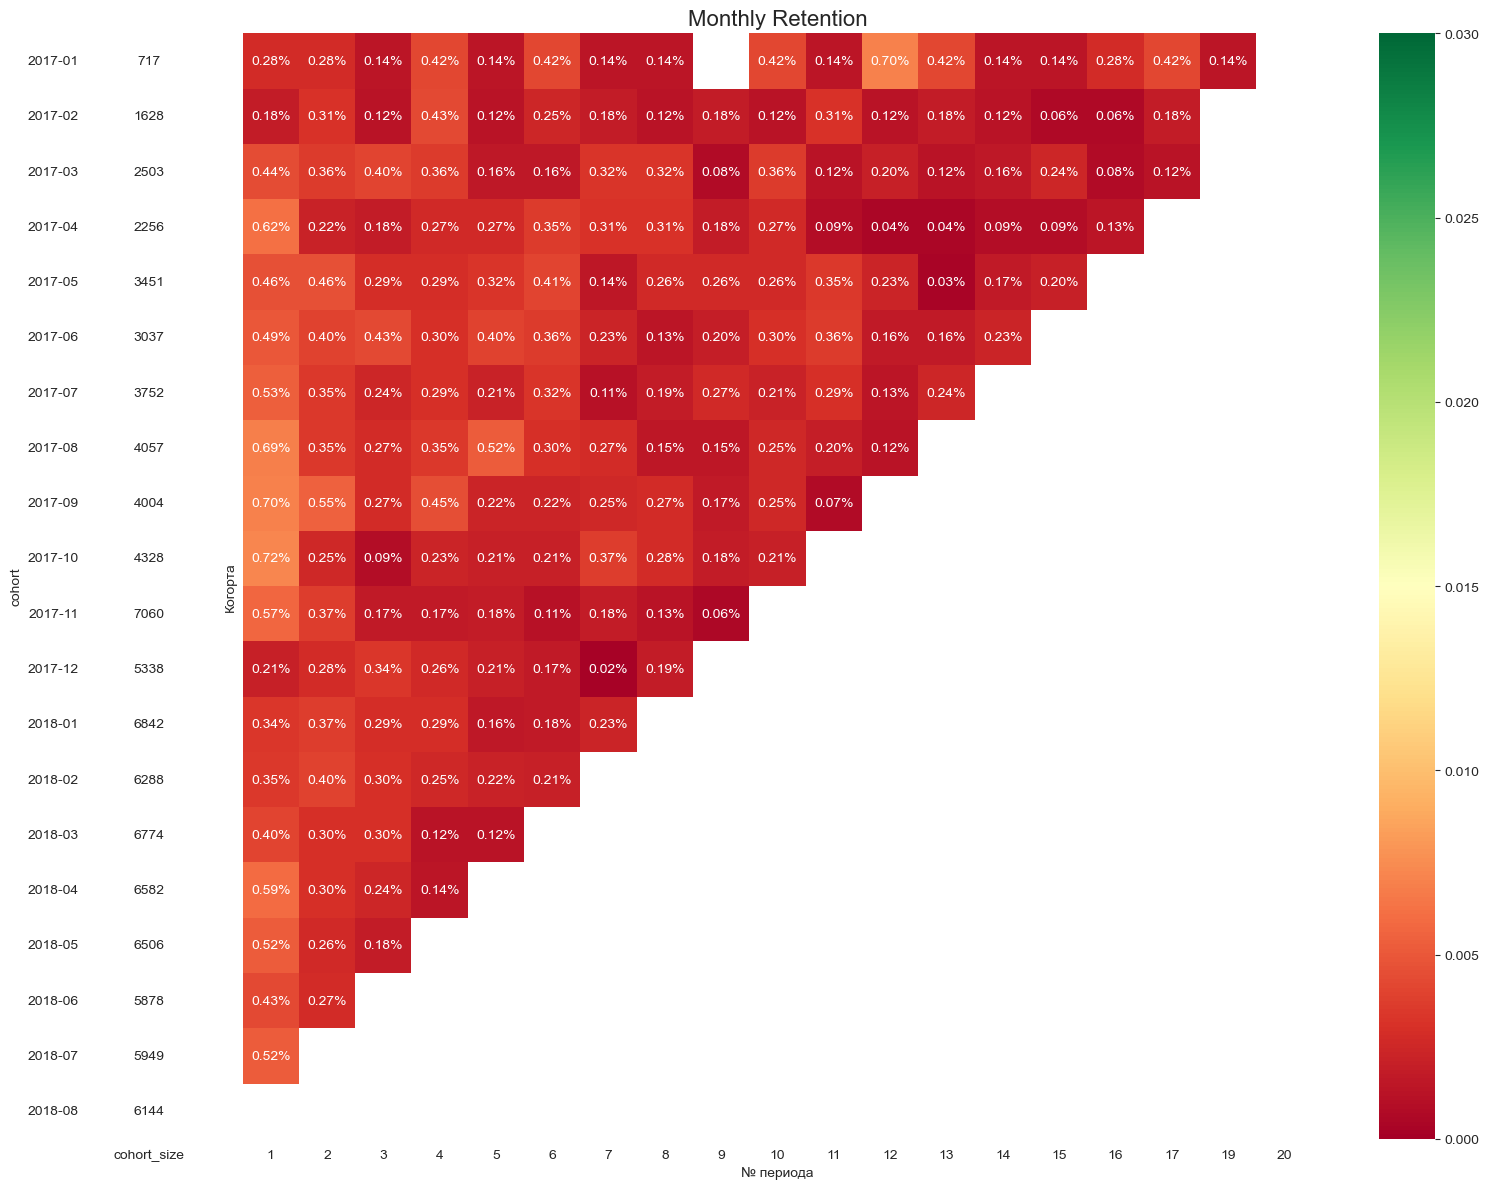

In [18]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                vmin=0,
                vmax=0.03,
                fmt='.2%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

### Выводы по 1-й цели:

Медианный retention первого месяца составляет 0.49%, что означает, что примерно 0.5% пользователей возвращаются в интернет-магазин для повторного оформления заказа в течение первого месяца после первой покупки.

Когорта июня 2017 года ('2017-06') демонстрирует наибольший retention на 3-й месяц, что может быть связано с другими факторами, например, сезонность или проведением маркетинговой акции в этот период.

## Цель 2: Определить соответствие интернет-магазина рынку (закрывает ли он потребности клиентов), существует ли product/market fit?

В рамках второй цели проекта были выполнены следующие задачи:

1. Проведена оценка наличия product/market fit у интернет-магазина c помощью визуализации retention во времени
2. Сделаны выводы относительно возможности масштабируемости продукта

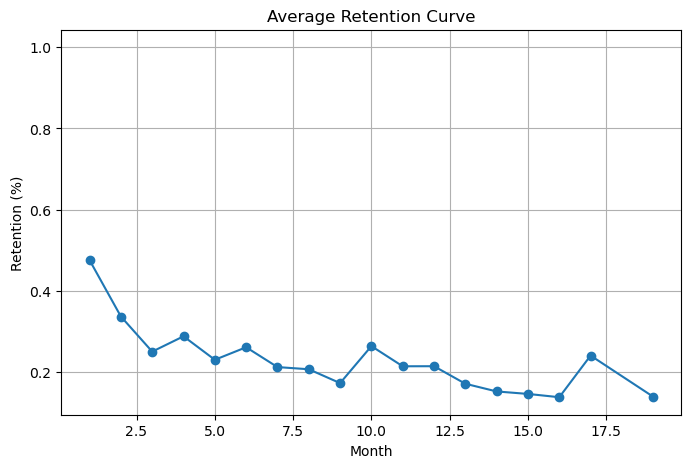

In [19]:
# Строим график PMF на основе retention

avg_retention = retention_matrix.mean() * 100

plt.figure(figsize=(8,5))
plt.plot(avg_retention.index, avg_retention.values, marker='o')
plt.axhline(1, linestyle='') # берем максимум 1% retention
plt.title('Average Retention Curve')
plt.xlabel('Month')
plt.ylabel('Retention (%)')
plt.grid(True)
plt.show()

## Выводы по 2 цели:

Нельзя утвержать, что маркетплейс имеет хороший PMF, так как наблюдается снижение к значениям бликим к 0.
Это означает, что подавляющее большинство пользователей совершают только одну покупку и не возвращаются на платформу интернет-магазина. Динамика retention свидетельствует о слабой пользовательской ценности продукта.

Для продуктов с устойчивым product/market fit обычно наблюдается стабилизация retention на определенном уровне (выход на стабильное "плато"), однако в данном случае retention быстро падает и остается на крайне низких значениях.

Таким образом, можно сделать вывод, что на текущий момент product/market fit у маркетплейса отсутствует. В соответствие с этим на данный момент переход к масштабируемости может вызвать дополнительные убытки. Необходимо сосредочиться на максимизации прибыли компании (об этом следующая цель).

## Цель 3: Определить основные продуктовые метрики, на которых можно сконцентрироваться для максимизации прибыли компании

В рамках второй цели проекта были выполнены следующие задачи, связанные с подбором метрик:

1. Была подобрана метрика, отражающая рост объема продаж интернет-магазина
2. Была подобрана метрика, отражающая объем аудитории, для которой интернет-магазин представляет ценность
3. Была подобрана метрика, отражающая уровень вовлеченности клиента в продолжение использования продукта (интернет-магазина)
4. Была подобрана метрика, отражающая денежное выражение вовлеченности клиента
5. Все метрики были визуализированы с месячной гранулярностью

#### Метрика 1 - GMV (Gross Merchandise Value) - общий объем продаж на платформе

In [20]:
df_for_gmv = df_orders.merge(df_order_items, on='order_id')

df_for_gmv['order_purchase_timestamp'] = pd.to_datetime(
    df_for_gmv['order_purchase_timestamp']
)

# GMV в разрезе по месяцам

df_for_gmv['order_month'] = df_for_gmv['order_purchase_timestamp'].dt.to_period('M')

gmv_month = (df_for_gmv.groupby('order_month').agg(gmv=('price', 'sum')))

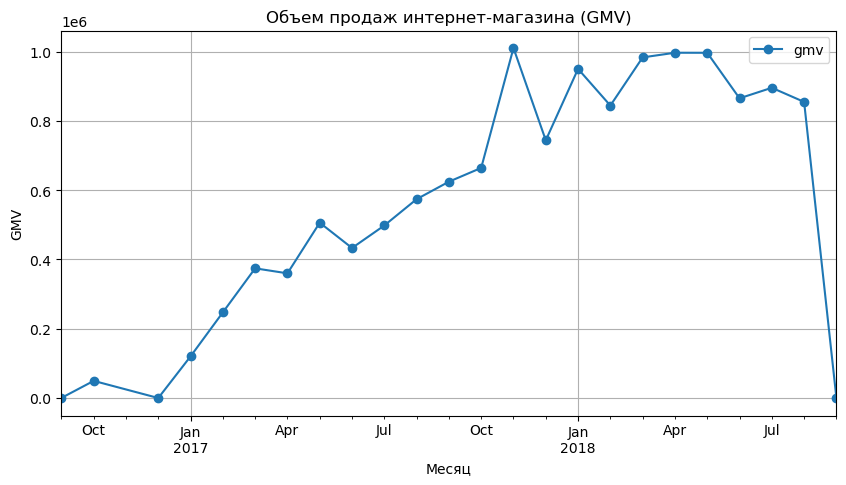

In [25]:
gmv_month.plot(figsize=(10,5), marker='o')
plt.title('Объем продаж интернет-магазина (GMV)')
plt.xlabel('Месяц')
plt.ylabel('GMV')
plt.grid()
plt.show()

#### Метрика 2 - MAU (monthly active users) число уникальных активных пользователей за месяц

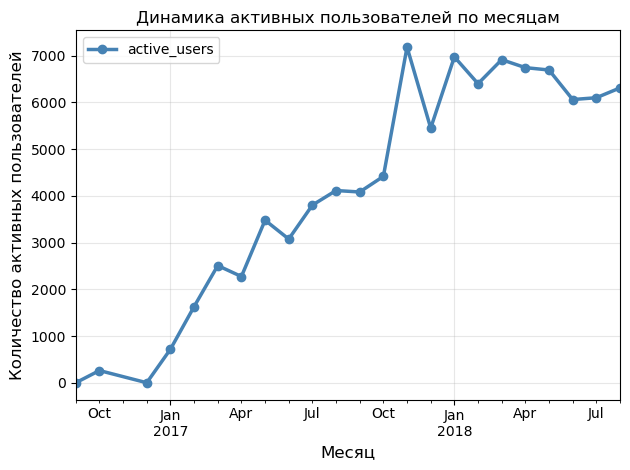

In [27]:
mau_score = df_orders_copy.groupby(['order_month'], as_index=False) \
    .agg(active_users=('customer_unique_id','nunique'))

# график
mau_score.plot(x='order_month', y='active_users', 
             color='steelblue', linewidth=2.5, marker='o', markersize=6)
plt.title('Динамика активных пользователей по месяцам', fontsize=12)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество активных пользователей', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Метрика 3 - Коэффициент повторных покупок (Repeat Purchase Rate, RPR)

Метрика свидетельствует об уровне вовлеченности клиента в продолжение использования продукта

Узнал о ней в статье - https://habr.com/ru/companies/otus/articles/659229/

In [28]:
orders_per_user_month = (df_orders_copy.groupby(['customer_unique_id','order_month']).size().reset_index(name='orders'))

repeat_users_month = (orders_per_user_month.groupby('order_month')
    .apply(lambda x: (x['orders'] >= 2).sum())
)

total_users_month = (orders_per_user_month.groupby('order_month')['customer_unique_id'].nunique())

repeat_rate_month = repeat_users_month / total_users_month

C:\Users\dimul\AppData\Local\Temp\ipykernel_18288\1730728338.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['orders'] >= 2).sum())


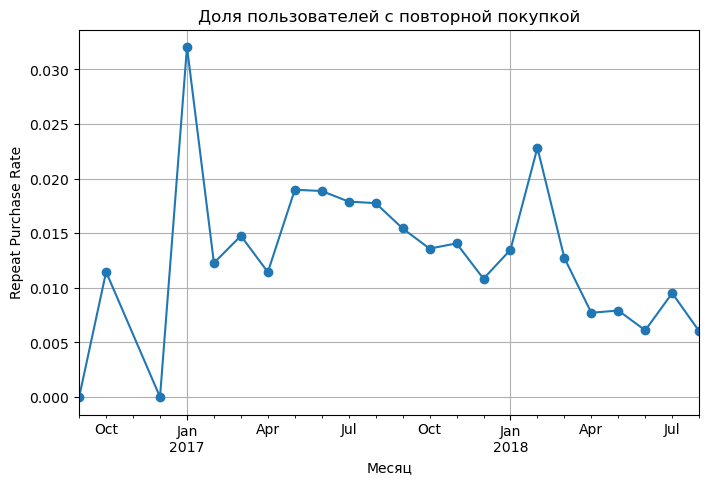

In [29]:
plt.figure(figsize=(8,5))

repeat_rate_month.plot(marker='o')
plt.title('Доля пользователей с повторной покупкой')
plt.xlabel('Месяц')
plt.ylabel('Repeat Purchase Rate')
plt.grid()
plt.show()

#### Метрика 4 - ARPPU (average revenue per paying user) — средняя выручка на платящего пользователя

In [34]:
# Метрика отражающая денежное выражение вовлеченности клиента

revenue_month = (df_for_gmv.groupby('order_month').agg(
        revenue=('price','sum'),
        users=('customer_unique_id','nunique')))

revenue_month['arppu'] = revenue_month['revenue'] / revenue_month['users']

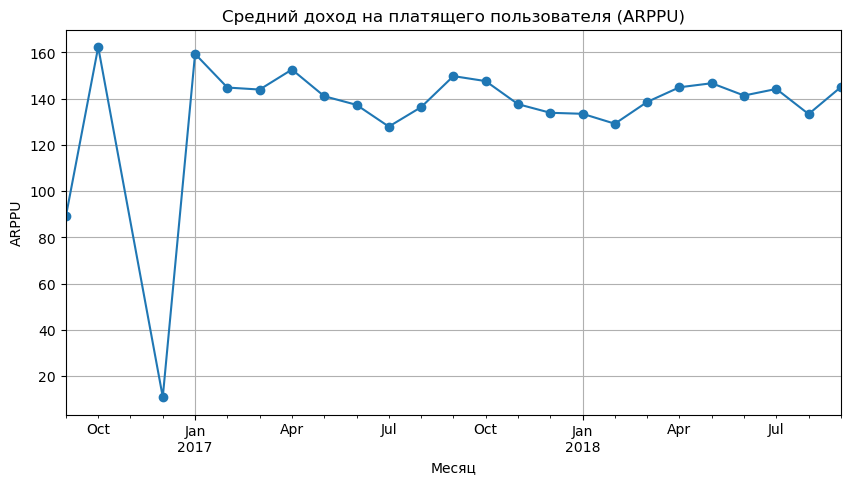

In [35]:
# График
revenue_month['arppu'].plot(figsize=(10,5), marker='o')

plt.title('Средний доход на платящего пользователя (ARPPU)')
plt.xlabel('Месяц')
plt.ylabel('ARPPU')
plt.grid()
plt.show()

In [39]:
# Общий средний доход на платящего пользователя (ARPPU) в месяц
revenue_month['arppu'].mean()

np.float64(134.617880268907)

## Выводы

Наиболее общим выводом будет то, что в продукте не наблюдается PMF, так как показатели Retention находятся на очень низких значениях и приближаются к 0. Пользователи крайне редко совершают повторные покупки, что свидетельствует о том, что они не видят ценности.

Несмотря на это график динамики уникальных активных пользователей по месяцам показывает рост. При этом доля повторных покупок держится на уровне 0,015. Средний чек на 1 платящего клиента составил примерно 134 рубля и колеблется в диапазоне +-10 рублей в зависимости от месяца.

На улучшении вышеуказанных целевых метриках следует сконцентрироваться, чтобы PMF интернет-магазина стабилизировался и вышел на плато.

**Дальнейший продуктовый анализ может включать в себя проверку гипотез об эффективности тех или иных изменений в продукте.**

Предполагаемая гипотеза, которую можно проверить в дальнейшем с помощью A/B тестирования: Сокращение времени до отгрузки заказа позволит клиента получать свои заказы без запаздывания, в связи с чем количество заказов увеличится за счет повторных заказов

Гипотеза говорит именно о росте повторных заказов, поэтому за целевую метрику я бы взял *конверсию пользователей в повторный заказ*, поскольку гипотеза предполагает, что более быстрая отгрузка увеличит вероятность повторной покупки (Repeat Purchase Rate).

В качестве прокси-метрики я бы взял - *Среднее время до отгрузки заказа*. Гипотеза связана со скоростью доставки.
В качестве guardrail-метрики стоит взять - *Долю отмененных заказов*.